In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

ROOT = Path.cwd().parent
df = pd.read_csv(ROOT / "data" / "processed" / "harga_pangan_manado_long.csv",
                parse_dates=["tanggal"])
varian = df[df["level"] == "varian"].copy()

print("Bentuk data  : ", df.shape)
print("Hanya varian : ", varian.shape)
varian.head()

Bentuk data  :  (13200, 5)
Hanya varian :  (8800, 5)


,komoditas,kategori,level,tanggal,harga
440,Bawang Merah Ukuran Sedang,Bawang Merah,varian,2025-01-01,47500.0
441,Bawang Merah Ukuran Sedang,Bawang Merah,varian,2025-01-02,46500.0
442,Bawang Merah Ukuran Sedang,Bawang Merah,varian,2025-01-03,46500.0
443,Bawang Merah Ukuran Sedang,Bawang Merah,varian,2025-01-06,46250.0
444,Bawang Merah Ukuran Sedang,Bawang Merah,varian,2025-01-07,45750.0


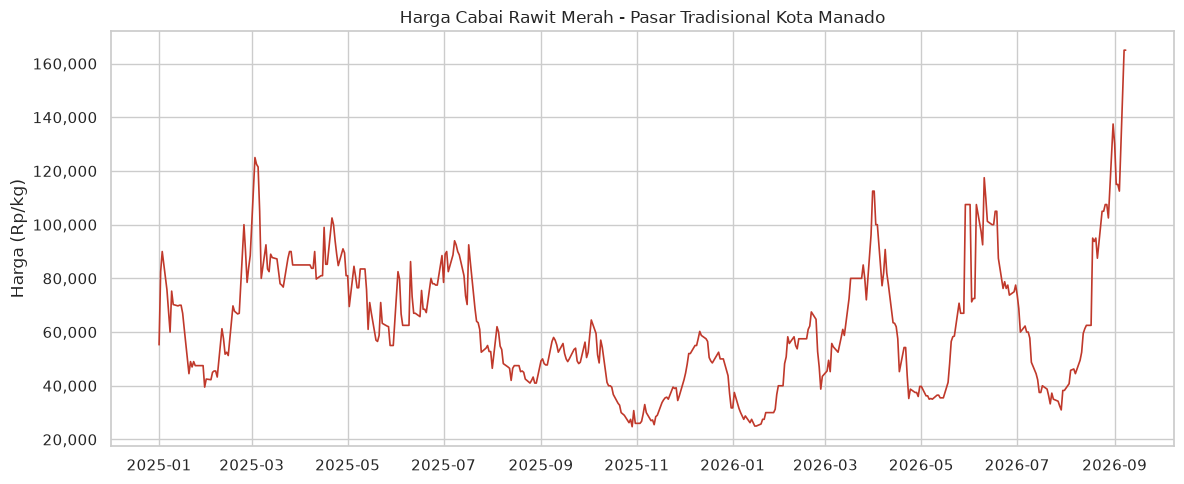

Terendah : Rp 24,750 pada 29 Oct 2025
Tertinggi: Rp 165,000 pada 07 Sep 2026


In [2]:
target = "Cabai Rawit Merah"
data = varian[varian["komoditas"] == target].sort_values("tanggal")

fig, ax = plt.subplots()
ax.plot(data["tanggal"], data["harga"], linewidth=1.2, color="#c0392b")
ax.set_title(f"Harga {target} - Pasar Tradisional Kota Manado")
ax.set_xlabel("")
ax.set_ylabel("Harga (Rp/kg)")
ax.yaxis.set_major_formatter(lambda x, p: f"{x:,.0f}")
plt.tight_layout()
plt.show()

print(f"Terendah : Rp {data['harga'].min():,.0f} pada {data.loc[data['harga'].idxmin(), 'tanggal']:%d %b %Y}")
print(f"Tertinggi: Rp {data['harga'].max():,.0f} pada {data.loc[data['harga'].idxmax(), 'tanggal']:%d %b %Y}")

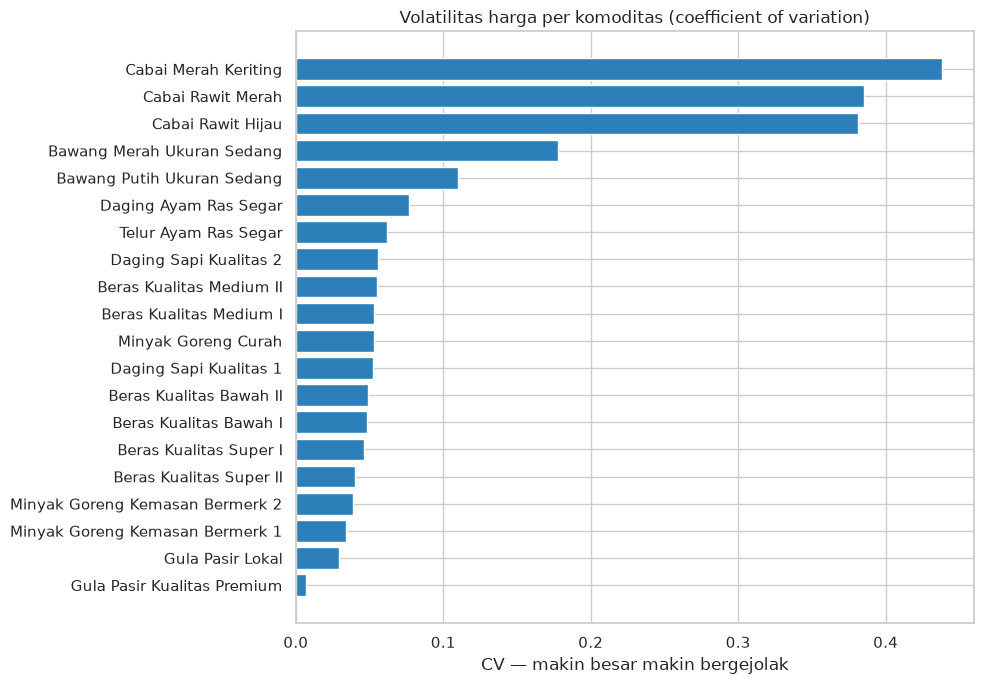

,rata,terendah,tertinggi,cv
komoditas,,,,
Cabai Merah Keriting,38083.636,11000.0,95000.0,0.438
Cabai Rawit Merah,61960.227,24750.0,165000.0,0.385
Cabai Rawit Hijau,56237.955,29000.0,137500.0,0.381
Bawang Merah Ukuran Sedang,47928.977,36250.0,101250.0,0.178
Bawang Putih Ukuran Sedang,40296.591,33750.0,67500.0,0.110
Daging Ayam Ras Segar,40272.727,36500.0,47750.0,0.077
Telur Ayam Ras Segar,30705.455,27400.0,34900.0,0.062
Daging Sapi Kualitas 2,132343.750,125000.0,150000.0,0.056
Beras Kualitas Medium II,15676.932,13900.0,16900.0,0.055


In [3]:
ringkas = (
    varian.groupby("komoditas")["harga"]
    .agg(rata="mean", terendah="min", tertinggi="max", stdev="std")
)
ringkas["rentang_relatif"] = (ringkas["tertinggi"] - ringkas["terendah"]) / ringkas["rata"]
ringkas["cv"] = ringkas["stdev"] / ringkas["rata"]
ringkas = ringkas.sort_values("cv", ascending=False).round(3)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(ringkas.index, ringkas["cv"], color="#2c7fb8")
ax.invert_yaxis()
ax.set_title("Volatilitas harga per komoditas (coefficient of variation)")
ax.set_xlabel("CV — makin besar makin bergejolak")
plt.tight_layout()
plt.show()

ringkas[["rata", "terendah", "tertinggi", "cv"]]

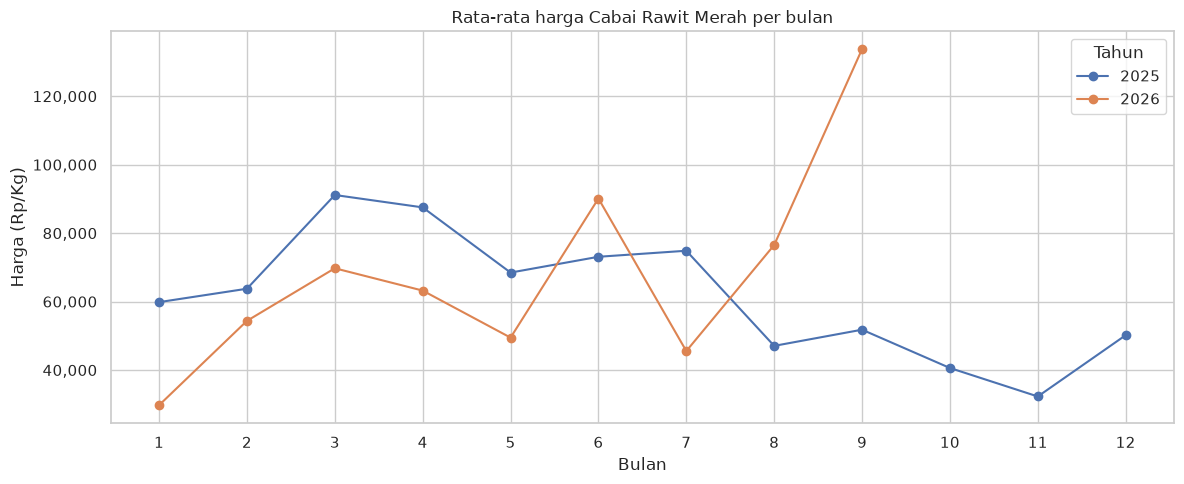

In [4]:
cabai = varian[varian["komoditas"] == "Cabai Rawit Merah"].copy()
cabai["tahun"] = cabai["tanggal"].dt.year
cabai["bulan"] = cabai["tanggal"].dt.month

bulanan = cabai.groupby(["tahun", "bulan"])["harga"].mean().reset_index()

fig, ax = plt.subplots()
for tahun, grup in bulanan.groupby("tahun"):
    ax.plot(grup["bulan"], grup["harga"], marker="o", label=str(tahun))

ax.set_title("Rata-rata harga Cabai Rawit Merah per bulan")
ax.set_xlabel("Bulan")
ax.set_ylabel("Harga (Rp/Kg)")
ax.set_xticks(range(1, 13))
ax.yaxis.set_major_formatter(lambda x, p: f"{x:,.0f}")
ax.legend(title="Tahun")
plt.tight_layout()
plt.show()

Korelasi harga hari ini dengan harga n hari lalu:
lag_1     0.939
lag_2     0.885
lag_3     0.859
lag_5     0.828
lag_7     0.722
lag_14    0.343
lag_30   -0.072


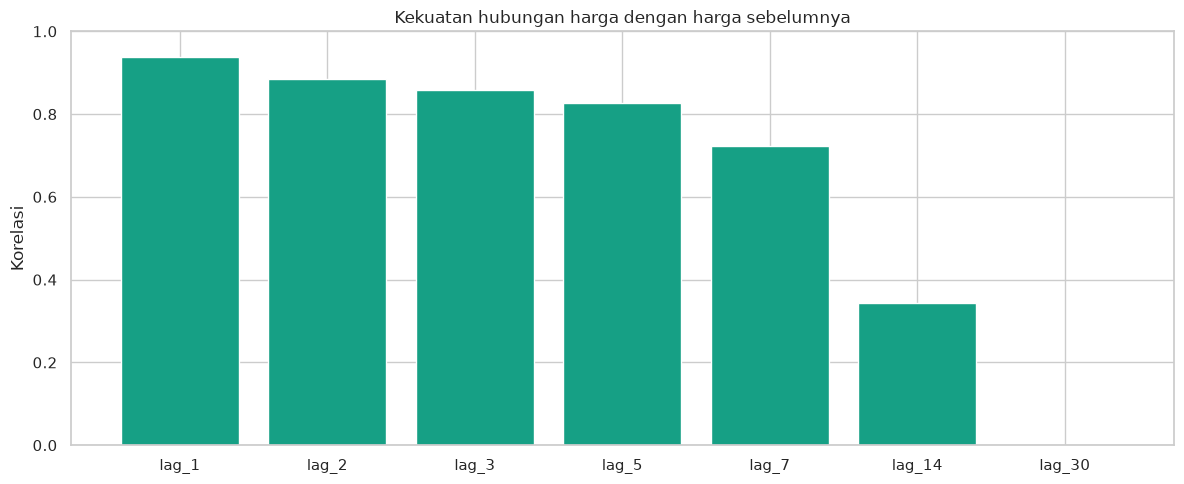

In [5]:
cabai_ts = cabai.sort_values("tanggal").set_index("tanggal")["harga"].astype(float)

lag_test = pd.DataFrame({"harga": cabai_ts})
for n in [1,2,3,5,7,14,30]:
    lag_test[f"lag_{n}"] = cabai_ts.shift(n)

korelasi = lag_test.corr()["harga"].drop("harga").round(3)
print("Korelasi harga hari ini dengan harga n hari lalu:")
print(korelasi.to_string())

fig, ax = plt.subplots()
ax.bar(korelasi.index, korelasi.values, color="#16a085")
ax.set_ylim(0, 1)
ax.set_title("Kekuatan hubungan harga dengan harga sebelumnya")
ax.set_ylabel("Korelasi")
plt.tight_layout()
plt.show()

In [6]:
def hitung_perubahan(seri):
    """Persentase perubahan harga dari observasi sebelumnya."""
    return seri.pct_change() * 100

anomali = varian.sort_values(["komoditas", "tanggal"]).copy()
anomali["harga"] = anomali["harga"].astype(float)
anomali["perubahan_pct"] = (
    anomali.groupby("komoditas")["harga"].transform(hitung_perubahan)
)

# ambang: perubahan lebih dari 3 standar deviasi milik komoditas itu sendiri
statistik = anomali.groupby("komoditas")["perubahan_pct"].agg(["mean", "std"])
anomali = anomali.join(statistik, on="komoditas", rsuffix="_stat")
anomali["z_score"] = (anomali["perubahan_pct"] - anomali["mean"]) / anomali["std"]
anomali["is_anomali"] = anomali["z_score"].abs() > 3

jumlah = anomali["is_anomali"].sum()
print(f"Total anomali terdeteksi: {jumlah} dari {len(anomali):,} observasi" 
        f"({jumlah / len(anomali) * 100:.2f}%)")

print("\n--- Anomali per komoditas ---")
per_kom = (
    anomali[anomali["is_anomali"]]
    .groupby("komoditas")
    .size()
    .sort_values(ascending=False)
)
print(per_kom.to_string())

print("\n--- 15 perubahan paling ekstrem ---")
top = (
    anomali.reindex(anomali["z_score"].abs().sort_values(ascending=False).index)
    .head(15)[["tanggal", "komoditas", "harga", "perubahan_pct", "z_score"]]
    .round(2)
)
print(top.to_string(index=False))

Total anomali terdeteksi: 221 dari 8,800 observasi(2.51%)

--- Anomali per komoditas ---
komoditas
Beras Kualitas Super I             19
Gula Pasir Lokal                   17
Beras Kualitas Bawah I             16
Daging Ayam Ras Segar              16
Minyak Goreng Kemasan Bermerk 1    13
Telur Ayam Ras Segar               13
Daging Sapi Kualitas 1             13
Beras Kualitas Medium I            13
Beras Kualitas Super II            12
Beras Kualitas Medium II           12
Daging Sapi Kualitas 2             11
Beras Kualitas Bawah II            10
Cabai Rawit Merah                  10
Cabai Rawit Hijau                   9
Cabai Merah Keriting                8
Bawang Merah Ukuran Sedang          8
Minyak Goreng Curah                 8
Bawang Putih Ukuran Sedang          6
Minyak Goreng Kemasan Bermerk 2     6
Gula Pasir Kualitas Premium         1

--- 15 perubahan paling ekstrem ---
   tanggal                       komoditas    harga  perubahan_pct  z_score
2025-09-09     Gula Pasir Ku

/tmp/ipykernel_2560/1517246542.py:34: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  .round(2)


In [8]:
hasil = varian.sort_values(["komoditas", "tanggal"]).copy()
hasil["harga"] = hasil["harga"].astype(float)

JENDELA = 30
AMBANG = 3.5

g = hasil.groupby("komoditas")["harga"]
hasil["perubahan_pct"] = g.transform(lambda s: s.pct_change() * 100)

p = hasil.groupby("komoditas")["perubahan_pct"]
hasil["median_roll"] = p.transform(
    lambda s: s.rolling(JENDELA, min_periods=10).median()
)

hasil["dev_abs"] = (hasil["perubahan_pct"] - hasil["median_roll"]).abs()
hasil["mad_roll"] = hasil.groupby("komoditas")["dev_abs"].transform(
    lambda s: s.rolling(JENDELA, min_periods=10).median()
)

hasil["skor_rolling"] = (
    (hasil["perubahan_pct"] - hasil["median_roll"]) / (hasil["mad_roll"] * 1.4826)
)
hasil["anomali_rolling"] = hasil["skor_rolling"].abs() > AMBANG

jml = int(hasil["anomali_rolling"].sum())
print(f"Total anomali: {jml} dari {len(hasil):,} observasi ({jml / len(hasil) * 100:.2f}%)\n")

print("Anomali per komoditas (metode rolling):")
print(
    hasil[hasil["anomali_rolling"]]
    .groupby("komoditas")
    .size()
    .sort_values(ascending=False)
    .to_string()
)

Total anomali: 771 dari 8,800 observasi (8.76%)

Anomali per komoditas (metode rolling):
komoditas
Bawang Merah Ukuran Sedang         99
Telur Ayam Ras Segar               81
Bawang Putih Ukuran Sedang         74
Daging Ayam Ras Segar              68
Cabai Rawit Hijau                  58
Cabai Merah Keriting               40
Beras Kualitas Medium II           39
Beras Kualitas Bawah I             39
Beras Kualitas Super II            37
Beras Kualitas Medium I            37
Beras Kualitas Super I             35
Cabai Rawit Merah                  33
Minyak Goreng Curah                29
Beras Kualitas Bawah II            26
Daging Sapi Kualitas 1             17
Gula Pasir Lokal                   16
Minyak Goreng Kemasan Bermerk 1    16
Daging Sapi Kualitas 2             15
Minyak Goreng Kemasan Bermerk 2    11
Gula Pasir Kualitas Premium         1


In [9]:
hasil = varian.sort_values(["komoditas", "tanggal"]).copy()
hasil["harga"] = hasil["harga"].astype(float)

JENDELA = 30
AMBANG = 4.0
MAD_MIN = 0.5   # lantai: perubahan di bawah 0.5% tidak dianggap sinyal

g = hasil.groupby("komoditas")["harga"]
hasil["perubahan_pct"] = g.transform(lambda s: s.pct_change() * 100)

p = hasil.groupby("komoditas")["perubahan_pct"]
hasil["median_roll"] = p.transform(
    lambda s: s.rolling(JENDELA, min_periods=10).median()
)

hasil["dev_abs"] = (hasil["perubahan_pct"] - hasil["median_roll"]).abs()
hasil["mad_roll"] = hasil.groupby("komoditas")["dev_abs"].transform(
    lambda s: s.rolling(JENDELA, min_periods=10).median()
)

# skala robust, dengan lantai
hasil["skala"] = (hasil["mad_roll"] * 1.4826).clip(lower=MAD_MIN)
hasil["skor_rolling"] = (hasil["perubahan_pct"] - hasil["median_roll"]) / hasil["skala"]

# syarat tambahan: perubahan harus material, minimal 5%
hasil["anomali_rolling"] = (
    (hasil["skor_rolling"].abs() > AMBANG)
    & (hasil["perubahan_pct"].abs() >= 5.0)
)

jml = int(hasil["anomali_rolling"].sum())
print(f"Total anomali: {jml} dari {len(hasil):,} observasi ({jml / len(hasil) * 100:.2f}%)\n")

print("Anomali per komoditas:")
print(
    hasil[hasil["anomali_rolling"]]
    .groupby("komoditas")
    .size()
    .sort_values(ascending=False)
    .to_string()
)

Total anomali: 163 dari 8,800 observasi (1.85%)

Anomali per komoditas:
komoditas
Cabai Rawit Hijau                  38
Bawang Merah Ukuran Sedang         35
Cabai Merah Keriting               32
Cabai Rawit Merah                  30
Bawang Putih Ukuran Sedang         14
Beras Kualitas Bawah II             5
Daging Ayam Ras Segar               4
Beras Kualitas Medium I             1
Beras Kualitas Medium II            1
Minyak Goreng Curah                 1
Minyak Goreng Kemasan Bermerk 2     1
Telur Ayam Ras Segar                1


In [ ]:
target = "Cabai Rawit Merah"
d = hasil[hasil["komoditas"] == target].sort_values("tanggal")
tanda = d[d["anomali_rolling"]]

fig, ax = plt.subplots()
ax.plot(d["tanggal"], d["harga"], linewidth=1, color="#7f8c8d", label="Harga")
ax.scatter(tanda["tanggal"], tanda["harga"], color="#e74c3c", s=45, zorder=5, label="Anomali")
ax.set_title(f"Deteksi anomali — {target}")
ax.set_ylabel("Harga (Rp/kg)")
ax.yaxis.set_major_formatter(lambda x, p: f"{x:,.0f}")
ax.legend()
plt.tight_layout()
plt.show()

print(f"{len(tanda)} anomali pada {target}:\n")
kolom = ["tanggal", "harga", "perubahan_pct", "skor_rolling"]
tampil = tanda[kolom].copy()
tampil["perubahan_pct"] = tampil["perubahan_pct"].round(2)
tampil["skor_rolling"] = tampil["skor_rolling"].round(2)
print(tampil.to_string(index=False))